# Linear Probe Evaluation for Morphology Classification

This notebook evaluates the AstroDINO model by training a linear classifier on top of frozen embeddings,
using `morph_flag_f150w` as the classification label.

In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from omegaconf import OmegaConf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Add project root to path
PROJECT_ROOT = "/u/yacheng/projects/ssl_outthere"
sys.path.insert(0, PROJECT_ROOT)

from dinov2.eval.setup import build_model_for_eval

# Import local modules
from dataset import JWSTMorphDataset
from models import LinearClassifier

/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [2]:
# Configuration
MODEL_CONFIG = "/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/config.yaml"
MODEL_WEIGHTS = "/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/eval/training_79999/teacher_checkpoint.pth"
DATA_ROOT = "/u/yacheng/projects/ssl_outthere/images/jwst/f150w"

BATCH_SIZE = 64
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda:0


## 1. Build Model for Evaluation

In [5]:
# Load model configuration and weights
cfg = OmegaConf.load(MODEL_CONFIG)
model = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model = model.to(DEVICE)
model.eval()
print(f"Model loaded successfully")
print(f"Crop size from config: {cfg.crops.global_crops_size}")

Model loaded successfully
Crop size from config: 64


## 2. Create Dataset

Dataset class is defined in `dataset.py`. Model classes are defined in `models.py`.

In [7]:
# Create dataset
crop_size = cfg.crops.global_crops_size
MAX_SAMPLES = -1  # Set to -1 for all samples after balancing
BALANCED = True   # Set to True to undersample majority classes to match minority class
SAMPLES_PER_CLASS = -1  # Set to a positive number for fixed samples per class (e.g., 10000)
DELTA_THRESHOLD = 0.01  # Only include samples with delta_f150w < this value (set to None to disable)

dataset = JWSTMorphDataset(
    DATA_ROOT, 
    crop_size=crop_size, 
    max_samples=MAX_SAMPLES,
    balanced=BALANCED,
    samples_per_class=SAMPLES_PER_CLASS,
    delta_threshold=DELTA_THRESHOLD
)
print(f"Dataset size: {len(dataset)}")

Loaded 20 files


Indexing valid samples: 100%|██████████| 20/20 [00:00<00:00, 608.47it/s]

Total valid samples (delta < 0.01): 1196
Original class counts: {2: 556, 0: 290, 1: 248, 3: 102}
Balancing to 102 samples per class
Label distribution:
  Class 0: 102 samples (25.0%)
  Class 1: 102 samples (25.0%)
  Class 2: 102 samples (25.0%)
  Class 3: 102 samples (25.0%)
Dataset size: 408


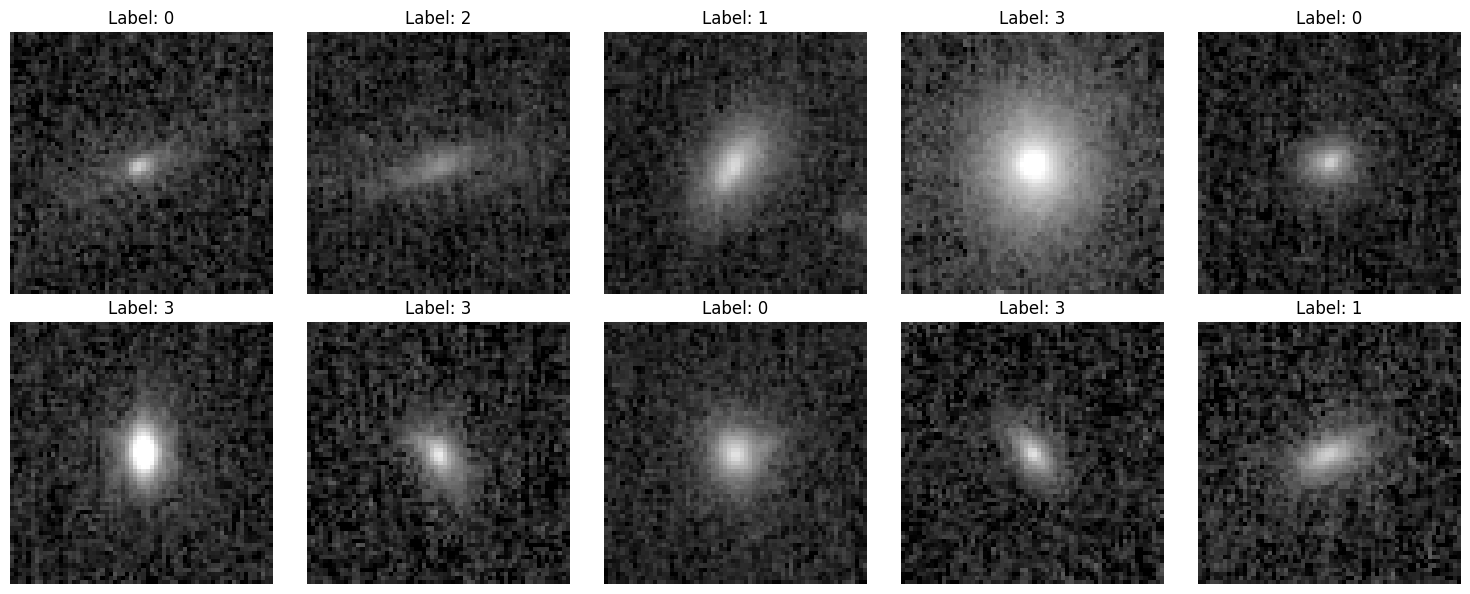

In [8]:
# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img, label = dataset[i]
    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()

## 3. Compute Embeddings

In [9]:
# Create DataLoader
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

# Compute embeddings
all_embeddings = []
all_labels = []

with torch.no_grad():
    for batch_imgs, batch_labels in tqdm(dataloader, desc="Computing embeddings"):
        batch_imgs = batch_imgs.to(DEVICE)
        
        # Get embeddings
        emb = model(batch_imgs)
        if isinstance(emb, tuple):
            emb = emb[0]
        
        # Flatten if needed
        if emb.dim() > 2:
            emb = emb.view(emb.size(0), -1)
        
        all_embeddings.append(emb.cpu().numpy())
        all_labels.append(batch_labels.numpy())

# Concatenate
embeddings = np.concatenate(all_embeddings, axis=0)
labels = np.concatenate(all_labels, axis=0)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")

Computing embeddings: 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]

Embeddings shape: (408, 768)
Labels shape: (408,)


## 4. Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Label distribution in train/test
print("\nTrain label distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(y_train):.1f}%)")

print("\nTest label distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(y_test):.1f}%)")

Train set: 326 samples
Test set: 82 samples

Train label distribution:
  Class 0: 81 (24.8%)
  Class 1: 82 (25.2%)
  Class 2: 81 (24.8%)
  Class 3: 82 (25.2%)

Test label distribution:
  Class 0: 21 (25.6%)
  Class 1: 20 (24.4%)
  Class 2: 21 (25.6%)
  Class 3: 20 (24.4%)


## 5. Linear Probe Training

In [11]:
# Define Linear Classifier (single linear layer for linear probe)
# Prepare data
num_classes = len(np.unique(labels))
in_dim = X_train.shape[1]

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets and DataLoaders
train_dataset_regress = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_regress = TensorDataset(X_test_tensor, y_test_tensor)

train_loader_regress = DataLoader(train_dataset_regress, batch_size=128, shuffle=True)
test_loader_regress = DataLoader(test_dataset_regress, batch_size=128, shuffle=False)

# Initialize model, optimizer, loss
clf = LinearClassifier(in_dim, num_classes).to(DEVICE)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

print(f"Linear Probe: input_dim={in_dim}, num_classes={num_classes}")

Linear Probe: input_dim=768, num_classes=4


## 6. Evaluation

Starting classification training...
Training on 326 samples, testing on 82 samples

Epoch   1: train_loss=1.5495, train_acc=23.31%, test_loss=1.5925, test_acc=23.17%
Epoch   2: train_loss=1.5252, train_acc=24.54%, test_loss=1.5695, test_acc=23.17%
Epoch   3: train_loss=1.5024, train_acc=25.46%, test_loss=1.5476, test_acc=24.39%
Epoch   4: train_loss=1.4811, train_acc=25.77%, test_loss=1.5266, test_acc=24.39%
Epoch   5: train_loss=1.4610, train_acc=26.38%, test_loss=1.5069, test_acc=26.83%
Epoch   6: train_loss=1.4408, train_acc=26.69%, test_loss=1.4883, test_acc=26.83%
Epoch   7: train_loss=1.4220, train_acc=28.22%, test_loss=1.4705, test_acc=26.83%
Epoch   8: train_loss=1.4036, train_acc=29.45%, test_loss=1.4534, test_acc=28.05%
Epoch   9: train_loss=1.3865, train_acc=30.98%, test_loss=1.4369, test_acc=30.49%
Epoch  10: train_loss=1.3696, train_acc=32.21%, test_loss=1.4213, test_acc=30.49%
Epoch  11: train_loss=1.3535, train_acc=33.74%, test_loss=1.4067, test_acc=32.93%
Epoch  12: tra

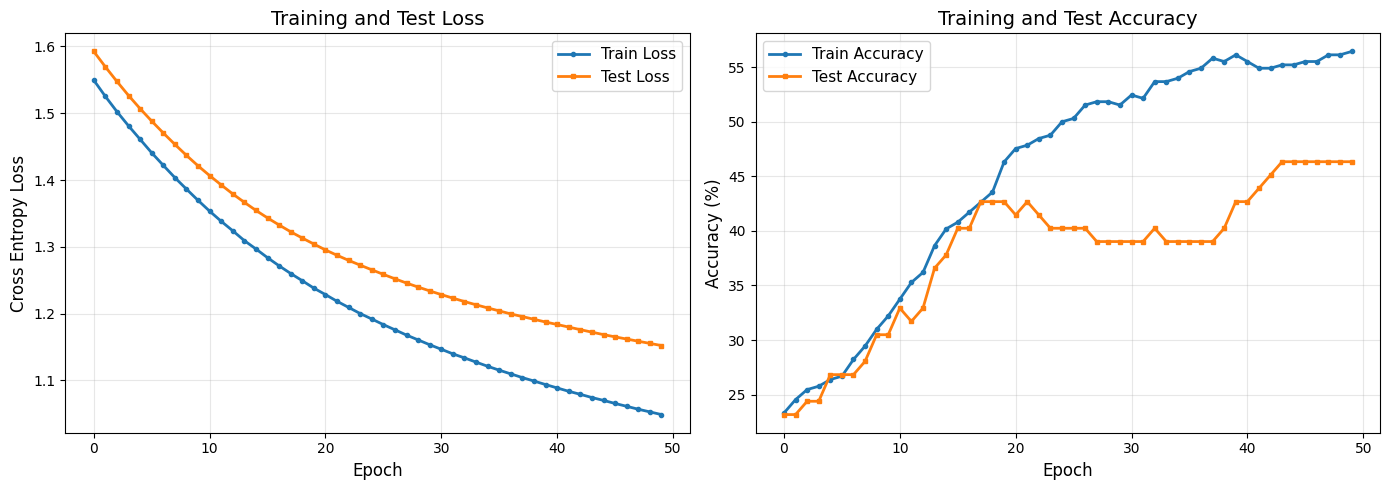

In [12]:
# Training Loop
num_epochs = 50
train_losses, test_losses = [], []
train_accs, test_accs = [], []

# Reset model and optimizer for fresh training
clf = LinearClassifier(in_dim, num_classes).to(DEVICE)
optimizer = torch.optim.Adam(clf.parameters(), lr=0.5e-4, weight_decay=1e-4)

print("Starting classification training...")
print(f"Training on {len(train_dataset_regress)} samples, testing on {len(test_dataset_regress)} samples\n")

for epoch in range(num_epochs):
    # Training
    clf.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for x, y in train_loader_regress:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        logits = clf(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == y).sum().item()
        train_total += x.size(0)
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Evaluation on test set
    clf.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for x, y in test_loader_regress:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = clf(x)
            loss = loss_fn(logits, y)
            
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            test_correct += (preds == y).sum().item()
            test_total += x.size(0)
    
    test_loss /= test_total
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1:3d}: train_loss={train_loss:.4f}, train_acc={train_acc*100:.2f}%, test_loss={test_loss:.4f}, test_acc={test_acc*100:.2f}%")

print("\nTraining complete!")

# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', linewidth=2, marker='o', markersize=3)
axes[0].plot(test_losses, label='Test Loss', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Cross Entropy Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Training and Test Loss', fontsize=14)

# Accuracy curve
axes[1].plot([a*100 for a in train_accs], label='Train Accuracy', linewidth=2, marker='o', markersize=3)
axes[1].plot([a*100 for a in test_accs], label='Test Accuracy', linewidth=2, marker='s', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Training and Test Accuracy', fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
# Final Evaluation
clf.eval()
y_pred_train = []
y_pred_test = []

with torch.no_grad():
    for x, _ in DataLoader(train_dataset_regress, batch_size=128, shuffle=False):
        x = x.to(DEVICE)
        preds = clf(x).argmax(dim=1).cpu().numpy()
        y_pred_train.append(preds)
    
    for x, _ in test_loader_regress:
        x = x.to(DEVICE)
        preds = clf(x).argmax(dim=1).cpu().numpy()
        y_pred_test.append(preds)

y_pred_train = np.concatenate(y_pred_train)
y_pred_test = np.concatenate(y_pred_test)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Final Train Accuracy: {train_acc*100:.2f}%")
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Final Train Accuracy: 56.75%
Final Test Accuracy: 46.34%


In [14]:
# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, digits=4))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.4348    0.4762    0.4545        21
           1     0.6316    0.6000    0.6154        20
           2     0.3846    0.2381    0.2941        21
           3     0.4074    0.5500    0.4681        20

    accuracy                         0.4634        82
   macro avg     0.4646    0.4661    0.4580        82
weighted avg     0.4633    0.4634    0.4560        82



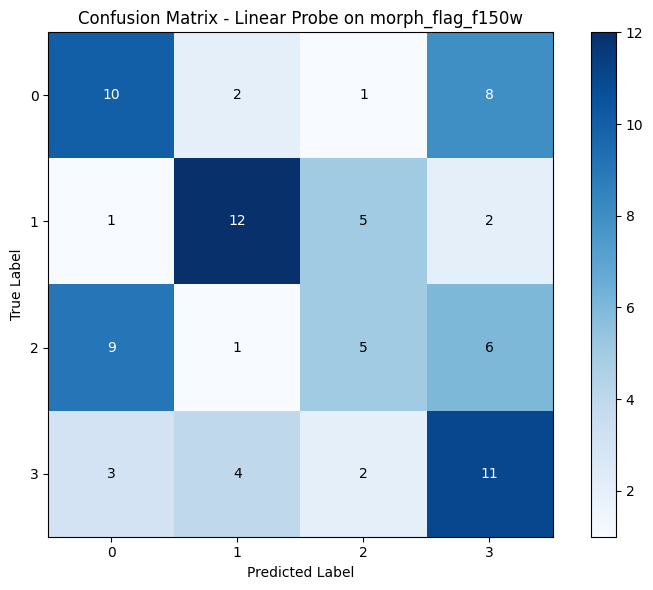

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Add labels
classes = sorted(np.unique(labels))
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Add values
for i in range(len(classes)):
    for j in range(len(classes)):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Linear Probe on morph_flag_f150w')
plt.colorbar(im)
plt.tight_layout()

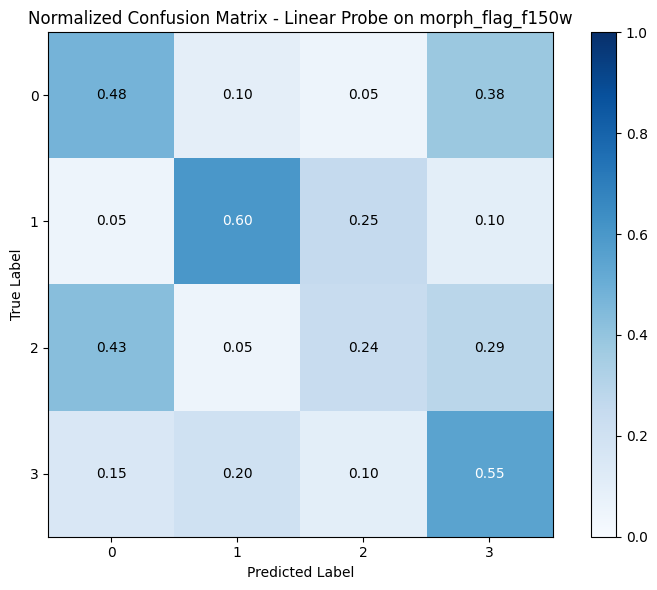

In [16]:
# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        text = ax.text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center", 
                       color="white" if cm_normalized[i, j] > 0.5 else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Normalized Confusion Matrix - Linear Probe on morph_flag_f150w')
plt.colorbar(im)
plt.tight_layout()

## 7. Baseline: Raw Pixels Linear Probe

Compare with a linear probe directly on raw image pixels (no pretrained model).

In [17]:
# Baseline: Flatten raw images and train linear probe
# Image size: 90x90 = 8100 dimensions

print("Computing raw pixel features (flattened images)...")

# Create DataLoader again
dataloader_raw = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

# Collect flattened images
all_raw_features = []
all_raw_labels = []

for batch_imgs, batch_labels in tqdm(dataloader_raw, desc="Flattening images"):
    # Flatten: (B, 1, 90, 90) -> (B, 8100)(only take the first channel since all channels are the same)
    flat = batch_imgs.view(batch_imgs.size(0), -1).numpy()
    all_raw_features.append(flat)
    all_raw_labels.append(batch_labels.numpy())

raw_features = np.concatenate(all_raw_features, axis=0)
raw_labels = np.concatenate(all_raw_labels, axis=0)

print(f"Raw features shape: {raw_features.shape}")  # Should be (N, 8100)
print(f"Raw labels shape: {raw_labels.shape}")

Computing raw pixel features (flattened images)...


Flattening images: 100%|██████████| 7/7 [00:00<00:00, 21.11it/s]

Raw features shape: (408, 12288)
Raw labels shape: (408,)


In [18]:
# Train/test split for raw pixels (use same random state for fair comparison)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    raw_features, raw_labels, test_size=0.2, random_state=42, stratify=raw_labels
)

print(f"Raw Train set: {X_train_raw.shape}")
print(f"Raw Test set: {X_test_raw.shape}")

# Convert to tensors
X_train_raw_tensor = torch.tensor(X_train_raw, dtype=torch.float32)
X_test_raw_tensor = torch.tensor(X_test_raw, dtype=torch.float32)
y_train_raw_tensor = torch.tensor(y_train_raw, dtype=torch.long)
y_test_raw_tensor = torch.tensor(y_test_raw, dtype=torch.long)

# Create DataLoaders
train_dataset_raw = TensorDataset(X_train_raw_tensor, y_train_raw_tensor)
test_dataset_raw = TensorDataset(X_test_raw_tensor, y_test_raw_tensor)
train_loader_raw = DataLoader(train_dataset_raw, batch_size=128, shuffle=True)
test_loader_raw = DataLoader(test_dataset_raw, batch_size=128, shuffle=False)

# Initialize raw pixel linear classifier
raw_in_dim = X_train_raw.shape[1]  # 24300
clf_raw = LinearClassifier(raw_in_dim, num_classes).to(DEVICE)
optimizer_raw = torch.optim.Adam(clf_raw.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Raw Pixel Linear Probe: input_dim={raw_in_dim}, num_classes={num_classes}")

Raw Train set: (326, 12288)
Raw Test set: (82, 12288)
Raw Pixel Linear Probe: input_dim=12288, num_classes=4


In [19]:
# Training Loop for Raw Pixels
num_epochs_raw = 50
train_losses_raw, test_losses_raw = [], []
train_accs_raw, test_accs_raw = [], []

# Reset model and optimizer for fresh training
clf_raw = LinearClassifier(raw_in_dim, num_classes).to(DEVICE)
optimizer_raw = torch.optim.Adam(clf_raw.parameters(), lr=1e-3, weight_decay=1e-4)

print("Starting RAW PIXEL baseline training...")
print(f"Training on {len(train_dataset_raw)} samples, testing on {len(test_dataset_raw)} samples\n")

for epoch in range(num_epochs_raw):
    # Training
    clf_raw.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for x, y in train_loader_raw:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        optimizer_raw.zero_grad()
        logits = clf_raw(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer_raw.step()
        
        train_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == y).sum().item()
        train_total += x.size(0)
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    train_losses_raw.append(train_loss)
    train_accs_raw.append(train_acc)
    
    # Evaluation
    clf_raw.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for x, y in test_loader_raw:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = clf_raw(x)
            loss = loss_fn(logits, y)
            
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            test_correct += (preds == y).sum().item()
            test_total += x.size(0)
    
    test_loss /= test_total
    test_acc = test_correct / test_total
    test_losses_raw.append(test_loss)
    test_accs_raw.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}: train_loss={train_loss:.4f}, train_acc={train_acc*100:.2f}%, test_loss={test_loss:.4f}, test_acc={test_acc*100:.2f}%")

print("\nRaw pixel baseline training complete!")

Starting RAW PIXEL baseline training...
Training on 326 samples, testing on 82 samples

Epoch   5: train_loss=1.4326, train_acc=30.37%, test_loss=1.3489, test_acc=31.71%
Epoch  10: train_loss=1.2501, train_acc=53.68%, test_loss=1.3259, test_acc=34.15%
Epoch  15: train_loss=1.1101, train_acc=61.96%, test_loss=1.3481, test_acc=35.37%
Epoch  20: train_loss=1.0319, train_acc=78.22%, test_loss=1.3157, test_acc=40.24%
Epoch  25: train_loss=1.0574, train_acc=65.64%, test_loss=1.3202, test_acc=35.37%
Epoch  30: train_loss=0.9216, train_acc=77.30%, test_loss=1.3543, test_acc=32.93%
Epoch  35: train_loss=0.8308, train_acc=87.73%, test_loss=1.3734, test_acc=34.15%
Epoch  40: train_loss=0.7631, train_acc=90.49%, test_loss=1.2996, test_acc=39.02%
Epoch  45: train_loss=0.7162, train_acc=89.88%, test_loss=1.3204, test_acc=40.24%
Epoch  50: train_loss=0.6879, train_acc=88.34%, test_loss=1.3646, test_acc=37.80%

Raw pixel baseline training complete!


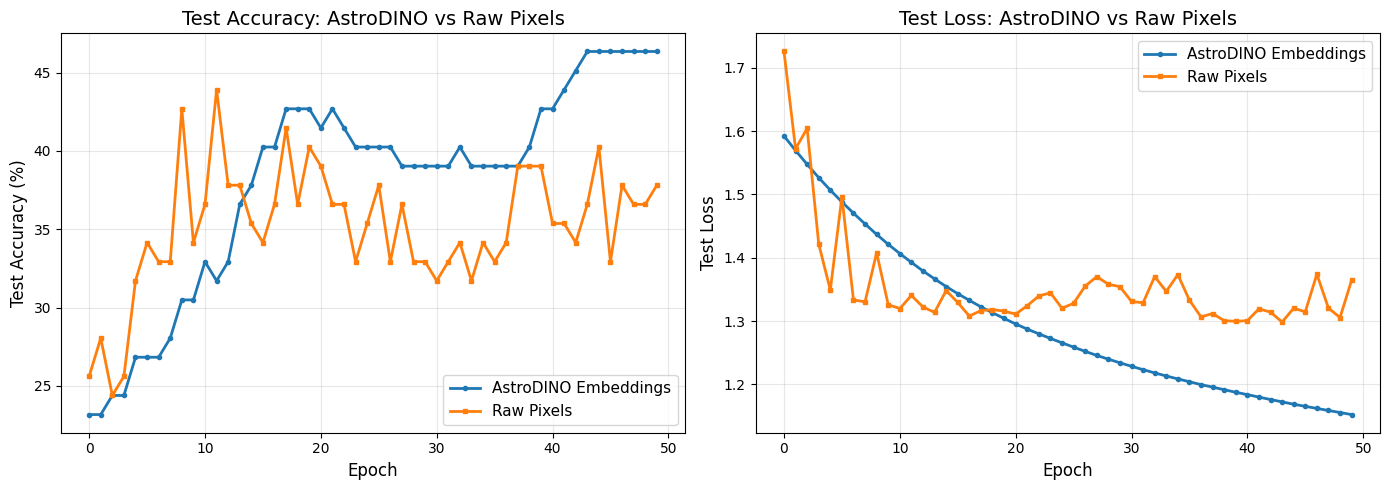


FINAL COMPARISON
AstroDINO Embeddings (dim=768):
  Best Test Accuracy: 46.34%
  Final Test Accuracy: 46.34%

Raw Pixels (dim=12288):
  Best Test Accuracy: 43.90%
  Final Test Accuracy: 37.80%
AstroDINO improvement over raw pixels: +2.44%


In [20]:
# Compare AstroDINO vs Raw Pixels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot([a*100 for a in test_accs], label='AstroDINO Embeddings', linewidth=2, marker='o', markersize=3)
axes[0].plot([a*100 for a in test_accs_raw], label='Raw Pixels', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Test Accuracy: AstroDINO vs Raw Pixels', fontsize=14)

# Loss comparison
axes[1].plot(test_losses, label='AstroDINO Embeddings', linewidth=2, marker='o', markersize=3)
axes[1].plot(test_losses_raw, label='Raw Pixels', linewidth=2, marker='s', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Test Loss: AstroDINO vs Raw Pixels', fontsize=14)

plt.tight_layout()
plt.show()

# Final comparison
print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)
print(f"AstroDINO Embeddings (dim={in_dim}):")
print(f"  Best Test Accuracy: {max(test_accs)*100:.2f}%")
print(f"  Final Test Accuracy: {test_accs[-1]*100:.2f}%")
print(f"\nRaw Pixels (dim={raw_in_dim}):")
print(f"  Best Test Accuracy: {max(test_accs_raw)*100:.2f}%")
print(f"  Final Test Accuracy: {test_accs_raw[-1]*100:.2f}%")
print("="*60)
improvement = max(test_accs) - max(test_accs_raw)
print(f"AstroDINO improvement over raw pixels: {improvement*100:+.2f}%")

## 8. Baseline: Random Initialized ViT (Same Architecture)

Compare with a randomly initialized ViT model (no pretraining) to isolate the contribution of self-supervised pretraining.

In [21]:
# Build a randomly initialized model with same architecture (no pretrained weights)
from dinov2.models import build_model_from_cfg

print("Building randomly initialized ViT model (same architecture, no pretraining)...")

# This creates a model with the same config but random weights
model_random, embed_dim_random = build_model_from_cfg(cfg, only_teacher=True)
model_random = model_random.to(DEVICE)
model_random.eval()

print(f"Random ViT model created, embed_dim={embed_dim_random}")
print(f"Architecture: {cfg.student.arch}")

Building randomly initialized ViT model (same architecture, no pretraining)...
Random ViT model created, embed_dim=768
Architecture: vit_base


In [22]:
# Compute embeddings with random ViT
print("Computing embeddings with random ViT...")

# Need to recreate dataset since it was closed
dataset_random = JWSTMorphDataset(
    DATA_ROOT, 
    crop_size=crop_size, 
    max_samples=MAX_SAMPLES,
    balanced=BALANCED,
    samples_per_class=SAMPLES_PER_CLASS,
    delta_threshold=DELTA_THRESHOLD
)

dataloader_random = DataLoader(dataset_random, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

all_embeddings_random = []
all_labels_random = []

with torch.no_grad():
    for batch_imgs, batch_labels in tqdm(dataloader_random, desc="Computing random ViT embeddings"):
        batch_imgs = batch_imgs.to(DEVICE)
        
        emb = model_random(batch_imgs)
        if isinstance(emb, tuple):
            emb = emb[0]
        if emb.dim() > 2:
            emb = emb.view(emb.size(0), -1)
        
        all_embeddings_random.append(emb.cpu().numpy())
        all_labels_random.append(batch_labels.numpy())

embeddings_random = np.concatenate(all_embeddings_random, axis=0)
labels_random = np.concatenate(all_labels_random, axis=0)

print(f"Random ViT embeddings shape: {embeddings_random.shape}")

# Clean up
dataset_random.close()
del model_random
torch.cuda.empty_cache()

Computing embeddings with random ViT...
Loaded 20 files


Indexing valid samples: 100%|██████████| 20/20 [00:00<00:00, 589.87it/s]


Total valid samples (delta < 0.01): 1196
Original class counts: {2: 556, 0: 290, 1: 248, 3: 102}
Balancing to 102 samples per class
Label distribution:
  Class 0: 102 samples (25.0%)
  Class 1: 102 samples (25.0%)
  Class 2: 102 samples (25.0%)
  Class 3: 102 samples (25.0%)


Computing random ViT embeddings: 100%|██████████| 7/7 [00:00<00:00, 13.60it/s]

Random ViT embeddings shape: (408, 768)


In [23]:
# Train/test split for random ViT embeddings (same random state)
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    embeddings_random, labels_random, test_size=0.2, random_state=42, stratify=labels_random
)

print(f"Random ViT - Train: {X_train_rand.shape}, Test: {X_test_rand.shape}")

# Convert to tensors
X_train_rand_tensor = torch.tensor(X_train_rand, dtype=torch.float32)
X_test_rand_tensor = torch.tensor(X_test_rand, dtype=torch.float32)
y_train_rand_tensor = torch.tensor(y_train_rand, dtype=torch.long)
y_test_rand_tensor = torch.tensor(y_test_rand, dtype=torch.long)

# Create DataLoaders
train_dataset_rand = TensorDataset(X_train_rand_tensor, y_train_rand_tensor)
test_dataset_rand = TensorDataset(X_test_rand_tensor, y_test_rand_tensor)
train_loader_rand = DataLoader(train_dataset_rand, batch_size=128, shuffle=True)
test_loader_rand = DataLoader(test_dataset_rand, batch_size=128, shuffle=False)

# Initialize classifier
rand_in_dim = X_train_rand.shape[1]
clf_rand = LinearClassifier(rand_in_dim, num_classes).to(DEVICE)
optimizer_rand = torch.optim.Adam(clf_rand.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Random ViT Linear Probe: input_dim={rand_in_dim}, num_classes={num_classes}")

Random ViT - Train: (326, 768), Test: (82, 768)
Random ViT Linear Probe: input_dim=768, num_classes=4


In [24]:
# Training Loop for Random ViT
num_epochs_rand = 50
train_losses_rand, test_losses_rand = [], []
train_accs_rand, test_accs_rand = [], []

# Reset model and optimizer
clf_rand = LinearClassifier(rand_in_dim, num_classes).to(DEVICE)
optimizer_rand = torch.optim.Adam(clf_rand.parameters(), lr=1e-3, weight_decay=1e-4)

print("Starting RANDOM VIT baseline training...")
print(f"Training on {len(train_dataset_rand)} samples, testing on {len(test_dataset_rand)} samples\n")

for epoch in range(num_epochs_rand):
    # Training
    clf_rand.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for x, y in train_loader_rand:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        optimizer_rand.zero_grad()
        logits = clf_rand(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer_rand.step()
        
        train_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == y).sum().item()
        train_total += x.size(0)
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    train_losses_rand.append(train_loss)
    train_accs_rand.append(train_acc)
    
    # Evaluation
    clf_rand.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for x, y in test_loader_rand:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = clf_rand(x)
            loss = loss_fn(logits, y)
            
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            test_correct += (preds == y).sum().item()
            test_total += x.size(0)
    
    test_loss /= test_total
    test_acc = test_correct / test_total
    test_losses_rand.append(test_loss)
    test_accs_rand.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}: train_loss={train_loss:.4f}, train_acc={train_acc*100:.2f}%, test_loss={test_loss:.4f}, test_acc={test_acc*100:.2f}%")

print("\nRandom ViT baseline training complete!")

Starting RANDOM VIT baseline training...
Training on 326 samples, testing on 82 samples

Epoch   5: train_loss=1.3999, train_acc=25.15%, test_loss=1.4020, test_acc=24.39%
Epoch  10: train_loss=1.4010, train_acc=25.15%, test_loss=1.3873, test_acc=24.39%
Epoch  15: train_loss=1.3917, train_acc=23.31%, test_loss=1.3909, test_acc=25.61%
Epoch  20: train_loss=1.4045, train_acc=22.39%, test_loss=1.3964, test_acc=24.39%
Epoch  25: train_loss=1.3975, train_acc=25.15%, test_loss=1.3915, test_acc=24.39%
Epoch  30: train_loss=1.3922, train_acc=23.31%, test_loss=1.3873, test_acc=25.61%
Epoch  35: train_loss=1.4028, train_acc=24.85%, test_loss=1.3944, test_acc=24.39%
Epoch  40: train_loss=1.4120, train_acc=19.33%, test_loss=1.4097, test_acc=24.39%
Epoch  45: train_loss=1.3906, train_acc=25.15%, test_loss=1.3908, test_acc=25.61%
Epoch  50: train_loss=1.3917, train_acc=24.85%, test_loss=1.3901, test_acc=25.61%

Random ViT baseline training complete!


## 9. Final Comparison: AstroDINO vs Random ViT vs Raw Pixels

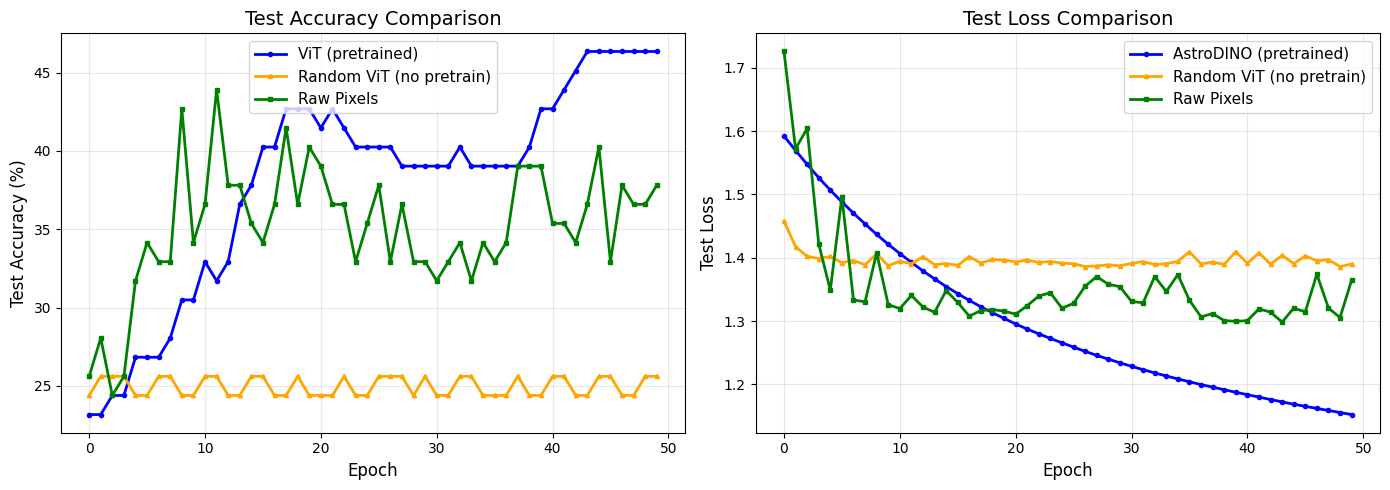


FINAL COMPARISON: Linear Probe on Morphology Classification

Method                                   Dim     Best Acc    Final Acc
--------------------------------------------------------------------------------
AstroDINO (pretrained)                   768       46.34%       46.34%
Random ViT (no pretrain)                 768       25.61%       25.61%
Raw Pixels                             12288       43.90%       37.80%

Improvement Analysis:
  AstroDINO vs Random ViT: +20.73%  (SSL pretraining contribution)
  AstroDINO vs Raw Pixels: +2.44%  (total model contribution)
  Random ViT vs Raw Pixels: -18.29%  (architecture contribution)



In [25]:
# Compare all three methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Accuracy comparison
axes[0].plot([a*100 for a in test_accs], label='ViT (pretrained)', linewidth=2, marker='o', markersize=3, color='blue')
axes[0].plot([a*100 for a in test_accs_rand], label='Random ViT (no pretrain)', linewidth=2, marker='^', markersize=3, color='orange')
axes[0].plot([a*100 for a in test_accs_raw], label='Raw Pixels', linewidth=2, marker='s', markersize=3, color='green')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Test Accuracy Comparison', fontsize=14)

# Test Loss comparison
axes[1].plot(test_losses, label='AstroDINO (pretrained)', linewidth=2, marker='o', markersize=3, color='blue')
axes[1].plot(test_losses_rand, label='Random ViT (no pretrain)', linewidth=2, marker='^', markersize=3, color='orange')
axes[1].plot(test_losses_raw, label='Raw Pixels', linewidth=2, marker='s', markersize=3, color='green')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Loss', fontsize=12)
axes[1].legend(fontsize=11,loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Test Loss Comparison', fontsize=14)

plt.tight_layout()
plt.show()

# Final summary table
print("\n" + "="*80)
print("FINAL COMPARISON: Linear Probe on Morphology Classification")
print("="*80)
print(f"\n{'Method':<35} {'Dim':>8} {'Best Acc':>12} {'Final Acc':>12}")
print("-"*80)
print(f"{'AstroDINO (pretrained)':<35} {in_dim:>8} {max(test_accs)*100:>11.2f}% {test_accs[-1]*100:>11.2f}%")
print(f"{'Random ViT (no pretrain)':<35} {rand_in_dim:>8} {max(test_accs_rand)*100:>11.2f}% {test_accs_rand[-1]*100:>11.2f}%")
print(f"{'Raw Pixels':<35} {raw_in_dim:>8} {max(test_accs_raw)*100:>11.2f}% {test_accs_raw[-1]*100:>11.2f}%")
print("="*80)

# Improvements
print("\nImprovement Analysis:")
astro_vs_rand = max(test_accs) - max(test_accs_rand)
astro_vs_raw = max(test_accs) - max(test_accs_raw)
rand_vs_raw = max(test_accs_rand) - max(test_accs_raw)

print(f"  AstroDINO vs Random ViT: {astro_vs_rand*100:+.2f}%  (SSL pretraining contribution)")
print(f"  AstroDINO vs Raw Pixels: {astro_vs_raw*100:+.2f}%  (total model contribution)")
print(f"  Random ViT vs Raw Pixels: {rand_vs_raw*100:+.2f}%  (architecture contribution)")

print("\n" + "="*80)

## 10. Unbalanced Dataset Experiment (max_samples=50000)

Train linear probe with unbalanced data to see how class imbalance affects performance.

In [28]:
# Create UNBALANCED dataset with max_samples=50000
MAX_SAMPLES_UB = 50000
BALANCED_UB = False  # No balancing
DELTA_THRESHOLD_UB = 0.01

print("="*60)
print("UNBALANCED DATASET EXPERIMENT")
print("="*60)

dataset_ub = JWSTMorphDataset(
    DATA_ROOT, 
    crop_size=crop_size, 
    max_samples=MAX_SAMPLES_UB,
    balanced=BALANCED_UB,
    samples_per_class=-1,
    delta_threshold=DELTA_THRESHOLD_UB
)
print(f"Unbalanced dataset size: {len(dataset_ub)}")

UNBALANCED DATASET EXPERIMENT
Loaded 20 files


Indexing valid samples: 100%|██████████| 20/20 [00:00<00:00, 34.62it/s]

Total valid samples (delta < 0.01): 1196
Label distribution:
  Class 0: 290 samples (24.2%)
  Class 1: 248 samples (20.7%)
  Class 2: 556 samples (46.5%)
  Class 3: 102 samples (8.5%)
Unbalanced dataset size: 1196


In [29]:
# Compute embeddings for unbalanced dataset
dataloader_ub = DataLoader(dataset_ub, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

all_embeddings_ub = []
all_labels_ub = []

with torch.no_grad():
    for batch_imgs, batch_labels in tqdm(dataloader_ub, desc="Computing embeddings (unbalanced)"):
        batch_imgs = batch_imgs.to(DEVICE)
        
        emb = model(batch_imgs)
        if isinstance(emb, tuple):
            emb = emb[0]
        if emb.dim() > 2:
            emb = emb.view(emb.size(0), -1)
        
        all_embeddings_ub.append(emb.cpu().numpy())
        all_labels_ub.append(batch_labels.numpy())

embeddings_ub = np.concatenate(all_embeddings_ub, axis=0)
labels_ub = np.concatenate(all_labels_ub, axis=0)

print(f"Unbalanced embeddings shape: {embeddings_ub.shape}")

# Show label distribution
print("\nLabel distribution (unbalanced):")
unique, counts = np.unique(labels_ub, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(labels_ub):.1f}%)")

dataset_ub.close()

Computing embeddings (unbalanced): 100%|██████████| 19/19 [00:32<00:00,  1.70s/it]

Unbalanced embeddings shape: (1196, 768)

Label distribution (unbalanced):
  Class 0: 290 (24.2%)
  Class 1: 248 (20.7%)
  Class 2: 556 (46.5%)
  Class 3: 102 (8.5%)


In [30]:
# Train/test split for unbalanced data
X_train_ub, X_test_ub, y_train_ub, y_test_ub = train_test_split(
    embeddings_ub, labels_ub, test_size=0.2, random_state=42, stratify=labels_ub
)

print(f"Unbalanced - Train: {X_train_ub.shape}, Test: {X_test_ub.shape}")

print("\nTrain label distribution (unbalanced):")
unique, counts = np.unique(y_train_ub, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(y_train_ub):.1f}%)")

print("\nTest label distribution (unbalanced):")
unique, counts = np.unique(y_test_ub, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(y_test_ub):.1f}%)")

Unbalanced - Train: (956, 768), Test: (240, 768)

Train label distribution (unbalanced):
  Class 0: 232 (24.3%)
  Class 1: 198 (20.7%)
  Class 2: 444 (46.4%)
  Class 3: 82 (8.6%)

Test label distribution (unbalanced):
  Class 0: 58 (24.2%)
  Class 1: 50 (20.8%)
  Class 2: 112 (46.7%)
  Class 3: 20 (8.3%)


In [31]:
# Prepare DataLoaders for unbalanced training
X_train_ub_tensor = torch.tensor(X_train_ub, dtype=torch.float32)
X_test_ub_tensor = torch.tensor(X_test_ub, dtype=torch.float32)
y_train_ub_tensor = torch.tensor(y_train_ub, dtype=torch.long)
y_test_ub_tensor = torch.tensor(y_test_ub, dtype=torch.long)

train_dataset_ub = TensorDataset(X_train_ub_tensor, y_train_ub_tensor)
test_dataset_ub = TensorDataset(X_test_ub_tensor, y_test_ub_tensor)
train_loader_ub = DataLoader(train_dataset_ub, batch_size=128, shuffle=True)
test_loader_ub = DataLoader(test_dataset_ub, batch_size=128, shuffle=False)

# Initialize classifier
ub_in_dim = X_train_ub.shape[1]
num_classes_ub = len(np.unique(labels_ub))
clf_ub = LinearClassifier(ub_in_dim, num_classes_ub).to(DEVICE)
optimizer_ub = torch.optim.Adam(clf_ub.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Unbalanced Linear Probe: input_dim={ub_in_dim}, num_classes={num_classes_ub}")

Unbalanced Linear Probe: input_dim=768, num_classes=4


In [32]:
# Training Loop for Unbalanced Dataset
num_epochs_ub = 50
train_losses_ub, test_losses_ub = [], []
train_accs_ub, test_accs_ub = [], []
train_f1s_ub, test_f1s_ub = [], []

# Reset model and optimizer
clf_ub = LinearClassifier(ub_in_dim, num_classes_ub).to(DEVICE)
optimizer_ub = torch.optim.Adam(clf_ub.parameters(), lr=1e-3, weight_decay=1e-4)

print("Starting UNBALANCED dataset training...")
print(f"Training on {len(train_dataset_ub)} samples, testing on {len(test_dataset_ub)} samples\n")

for epoch in range(num_epochs_ub):
    # Training
    clf_ub.train()
    train_loss = 0
    train_preds_all, train_labels_all = [], []
    
    for x, y in train_loader_ub:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        optimizer_ub.zero_grad()
        logits = clf_ub(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer_ub.step()
        
        train_loss += loss.item() * x.size(0)
        train_preds_all.append(logits.argmax(dim=1).cpu().numpy())
        train_labels_all.append(y.cpu().numpy())
    
    train_preds_all = np.concatenate(train_preds_all)
    train_labels_all = np.concatenate(train_labels_all)
    train_loss /= len(train_preds_all)
    train_acc = accuracy_score(train_labels_all, train_preds_all)
    train_f1 = f1_score(train_labels_all, train_preds_all, average='weighted')
    
    train_losses_ub.append(train_loss)
    train_accs_ub.append(train_acc)
    train_f1s_ub.append(train_f1)
    
    # Evaluation
    clf_ub.eval()
    test_loss = 0
    test_preds_all, test_labels_all = [], []
    
    with torch.no_grad():
        for x, y in test_loader_ub:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = clf_ub(x)
            loss = loss_fn(logits, y)
            
            test_loss += loss.item() * x.size(0)
            test_preds_all.append(logits.argmax(dim=1).cpu().numpy())
            test_labels_all.append(y.cpu().numpy())
    
    test_preds_all = np.concatenate(test_preds_all)
    test_labels_all = np.concatenate(test_labels_all)
    test_loss /= len(test_preds_all)
    test_acc = accuracy_score(test_labels_all, test_preds_all)
    test_f1 = f1_score(test_labels_all, test_preds_all, average='weighted')
    
    test_losses_ub.append(test_loss)
    test_accs_ub.append(test_acc)
    test_f1s_ub.append(test_f1)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}: train_acc={train_acc*100:.2f}%, test_acc={test_acc*100:.2f}%, test_f1={test_f1:.4f}")

print("\nUnbalanced training complete!")

Starting UNBALANCED dataset training...
Training on 956 samples, testing on 240 samples

Epoch   5: train_acc=55.23%, test_acc=42.50%, test_f1=0.4207
Epoch  10: train_acc=59.31%, test_acc=44.58%, test_f1=0.4371
Epoch  15: train_acc=60.67%, test_acc=43.75%, test_f1=0.4276
Epoch  20: train_acc=62.76%, test_acc=43.75%, test_f1=0.4268
Epoch  25: train_acc=65.59%, test_acc=45.00%, test_f1=0.4454
Epoch  30: train_acc=66.84%, test_acc=42.92%, test_f1=0.4180
Epoch  35: train_acc=68.20%, test_acc=42.08%, test_f1=0.4177
Epoch  40: train_acc=68.93%, test_acc=44.17%, test_f1=0.4352
Epoch  45: train_acc=68.51%, test_acc=43.75%, test_f1=0.4340
Epoch  50: train_acc=69.67%, test_acc=45.42%, test_f1=0.4502

Unbalanced training complete!


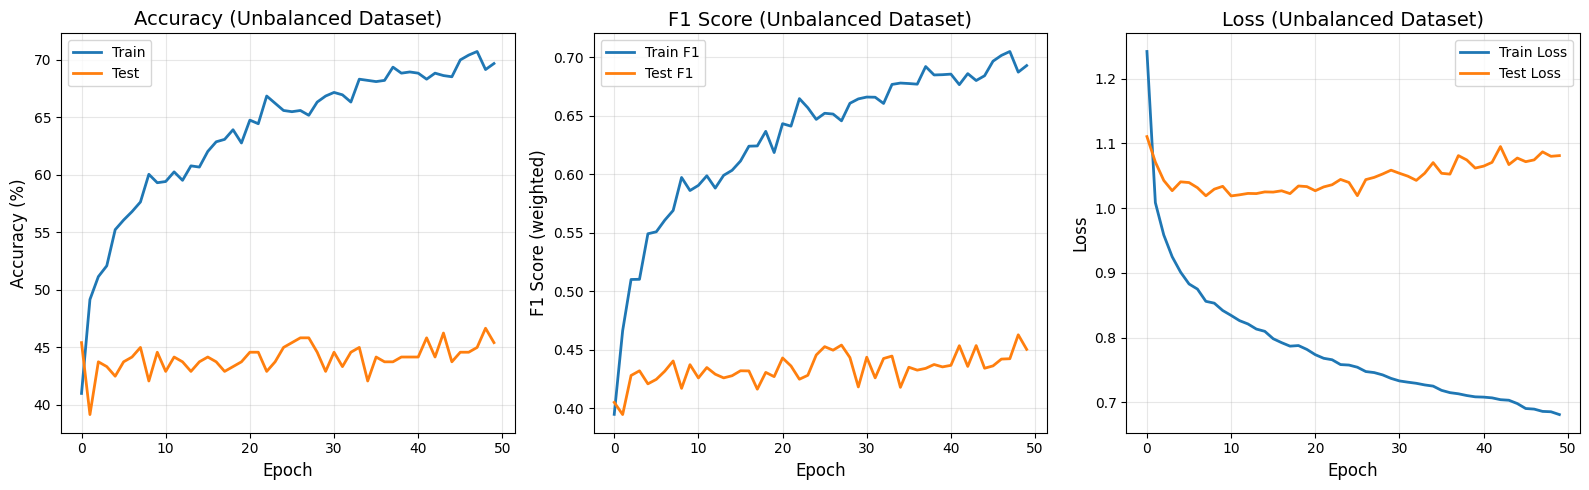

In [33]:
# Plot training curves for unbalanced dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].plot([a*100 for a in train_accs_ub], label='Train', linewidth=2)
axes[0].plot([a*100 for a in test_accs_ub], label='Test', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Accuracy (Unbalanced Dataset)', fontsize=14)

# F1 Score
axes[1].plot(train_f1s_ub, label='Train F1', linewidth=2)
axes[1].plot(test_f1s_ub, label='Test F1', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('F1 Score (weighted)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title('F1 Score (Unbalanced Dataset)', fontsize=14)

# Loss
axes[2].plot(train_losses_ub, label='Train Loss', linewidth=2)
axes[2].plot(test_losses_ub, label='Test Loss', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Loss', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Loss (Unbalanced Dataset)', fontsize=14)

plt.tight_layout()
plt.show()


Classification Report (Unbalanced Test Set):
              precision    recall  f1-score   support

           0     0.4000    0.4483    0.4228        58
           1     0.5143    0.3600    0.4235        50
           2     0.4919    0.5446    0.5169       112
           3     0.2500    0.2000    0.2222        20

    accuracy                         0.4542       240
   macro avg     0.4141    0.3882    0.3964       240
weighted avg     0.4542    0.4542    0.4502       240



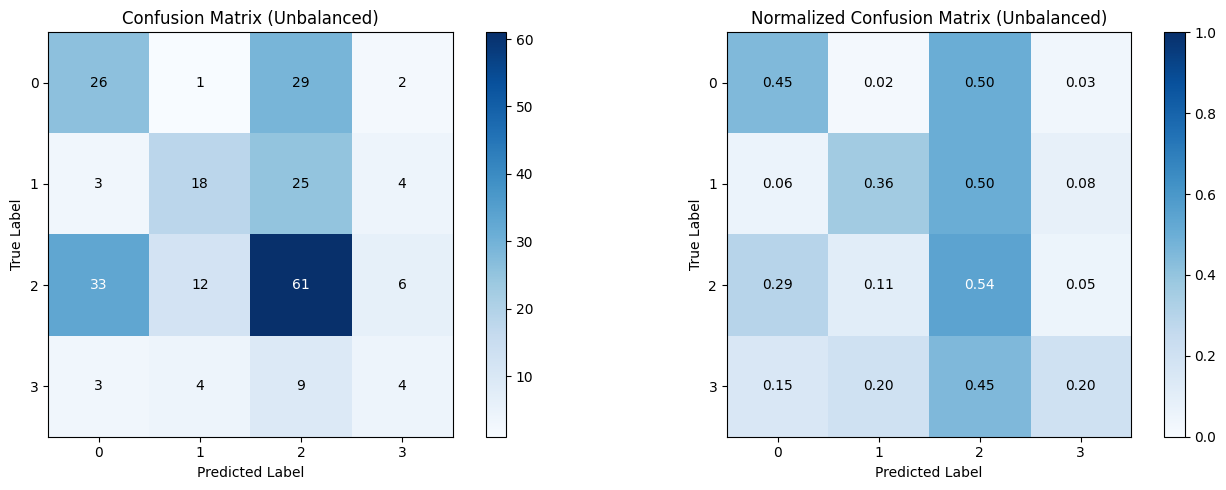

In [34]:
# Classification report and confusion matrix for unbalanced
print("\nClassification Report (Unbalanced Test Set):")
print(classification_report(test_labels_all, test_preds_all, digits=4))

# Confusion matrix
cm_ub = confusion_matrix(test_labels_all, test_preds_all)
cm_ub_normalized = cm_ub.astype('float') / cm_ub.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
ax = axes[0]
classes_ub = sorted(np.unique(labels_ub))
im = ax.imshow(cm_ub, cmap='Blues')
ax.set_xticks(range(len(classes_ub)))
ax.set_yticks(range(len(classes_ub)))
ax.set_xticklabels(classes_ub)
ax.set_yticklabels(classes_ub)
for i in range(len(classes_ub)):
    for j in range(len(classes_ub)):
        ax.text(j, i, cm_ub[i, j], ha="center", va="center", 
                color="white" if cm_ub[i, j] > cm_ub.max()/2 else "black")
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix (Unbalanced)')
plt.colorbar(im, ax=ax)

# Normalized
ax = axes[1]
im = ax.imshow(cm_ub_normalized, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(classes_ub)))
ax.set_yticks(range(len(classes_ub)))
ax.set_xticklabels(classes_ub)
ax.set_yticklabels(classes_ub)
for i in range(len(classes_ub)):
    for j in range(len(classes_ub)):
        ax.text(j, i, f"{cm_ub_normalized[i, j]:.2f}", ha="center", va="center", 
                color="white" if cm_ub_normalized[i, j] > 0.5 else "black")
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Normalized Confusion Matrix (Unbalanced)')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [35]:
# Compare Balanced vs Unbalanced performance
print("\n" + "="*80)
print("BALANCED vs UNBALANCED COMPARISON")
print("="*80)

print(f"\n{'Dataset':<25} {'Samples':>10} {'Best Acc':>12} {'Best F1':>12}")
print("-"*80)
print(f"{'Balanced':<25} {len(embeddings):>10} {max(test_accs)*100:>11.2f}% {'-':>12}")
print(f"{'Unbalanced (50k)':<25} {len(embeddings_ub):>10} {max(test_accs_ub)*100:>11.2f}% {max(test_f1s_ub):>12.4f}")
print("="*80)

# Per-class comparison
print("\nPer-class Recall (Normalized CM diagonal):")
print(f"{'Class':<10} {'Balanced':>15} {'Unbalanced':>15}")
print("-"*45)
for i, cls in enumerate(classes_ub):
    balanced_recall = cm_normalized[i, i] if i < len(cm_normalized) else float('nan')
    unbalanced_recall = cm_ub_normalized[i, i]
    print(f"{cls:<10} {balanced_recall*100:>14.2f}% {unbalanced_recall*100:>14.2f}%")


BALANCED vs UNBALANCED COMPARISON

Dataset                      Samples     Best Acc      Best F1
--------------------------------------------------------------------------------
Balanced                         408       46.34%            -
Unbalanced (50k)                1196       46.67%       0.4626

Per-class Recall (Normalized CM diagonal):
Class             Balanced      Unbalanced
---------------------------------------------
0                   47.62%          44.83%
1                   60.00%          36.00%
2                   23.81%          54.46%
3                   55.00%          20.00%


In [ ]:
# Clean up
dataset.close()
print("Dataset closed.")